1---Imports of libraries

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   - -------------------------------------- 3.1/123.0 MB 15.8 MB/s eta 0:00:08
   -- ------------------------------------- 7.3/123.0 MB 17.4 MB/s eta 0:00:07
   --- ------------------------------------ 11.0/123.0 MB 17.4 MB/s eta 0:00:07
   ---- ----------------------------------- 14.7/123.0 MB 17.1 MB/s eta 0:00:07
   ----- ---------------------------------- 17.6/123.0 MB 16.5 MB/s eta 0:00:07
   ------ --------------------------------- 18.9/123.0 MB 14.6 MB/s eta 0:00:08
   ------ --------------------------------- 19.7/123.0 MB 13.3 MB/s eta 0:00:08
   ------ --------------------------------- 21.5/123.0 MB 12.5 MB/s eta 0:00:09
   ------- ----------------------


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


2---Load the dataset

In [8]:
df = pd.read_csv(
    r'C:\Users\ASUS\Downloads\individual+household+electric+power+consumption\household_power_consumption.txt',
    sep=';',
    na_values='?',
    low_memory=False
)
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 Rows")
df.head()

Dataset Shape: (2075259, 9)

Columns: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

First 5 Rows


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [7]:
print("Missing Values per Column")
print(df.isnull().sum())

Missing Values per Column
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64


3---Combining The Date And Time

In [9]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.drop(columns=['Date', 'Time'], inplace=True)
df.set_index('Datetime', inplace=True)
df.sort_index(inplace=True)

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [10]:
df.ffill(inplace=True)

print("Missing values after fill:", df.isnull().sum().sum())
print("Date Range:", df.index.min(), "to", df.index.max())

Missing values after fill: 0
Date Range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00


In [11]:
hourly = df['Global_active_power'].resample('h').mean()
hourly = hourly.ffill()

print("Hourly Series Shape:", hourly.shape)
hourly.head()

Hourly Series Shape: (34589,)


Datetime
2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float64

count    34589.000000
mean         1.086200
std          0.894942
min          0.124000
25%          0.341267
50%          0.799533
75%          1.574967
max          6.560533
Name: Global_active_power, dtype: float64


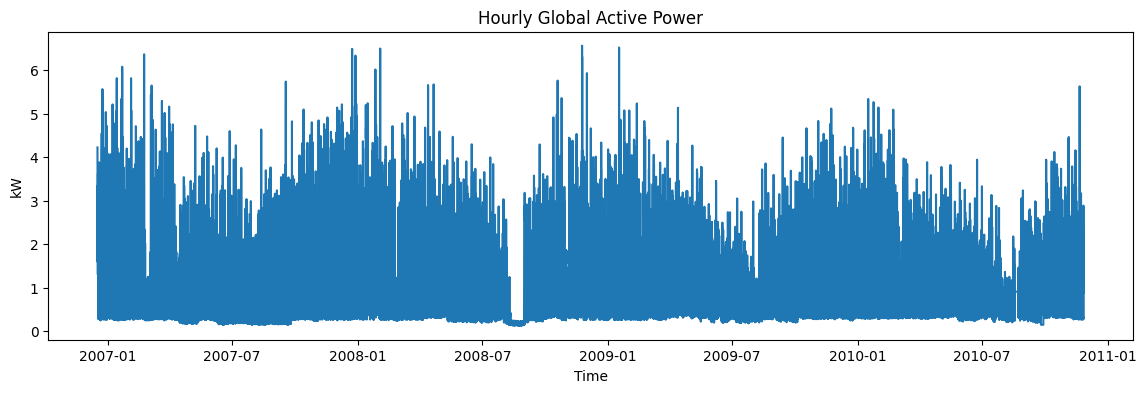

In [12]:
print(hourly.describe())

plt.figure(figsize=(14, 4))
plt.plot(hourly.index, hourly.values)
plt.title("Hourly Global Active Power")
plt.xlabel("Time")
plt.ylabel("kW")
plt.show()

In [13]:
values = hourly.values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_values = scaler.fit_transform(values)

scaled_values[:10]

array([[0.63681623],
       [0.54504495],
       [0.50900588],
       [0.48854974],
       [0.45559722],
       [0.32255458],
       [0.30103161],
       [0.27320089],
       [0.50110826],
       [0.2273377 ]])

In [ ]:
window_size = 24   # using 24 hours to predict the next hour

X, y = [], []
for i in range(window_size, len(scaled_values)):
    X.append(scaled_values[i-window_size:i, 0])   # window of 24 past readings
    y.append(scaled_values[i, 0])                 # value to predict

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (34565, 24)
y shape: (34565,)


In [15]:
split_idx = int(len(X) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 27652
Test size: 6913


In [16]:
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

X_train_t.shape, y_train_t.shape

(torch.Size([27652, 24, 1]), torch.Size([27652]))

In [17]:
class CustomDataset(Dataset):

  def __init__(self, X, y):
    self.X = X
    self.y = y

  def __len__(self):    # returns total samples
    return self.X.shape[0]

  def __getitem__(self, idx):    # returns one training example
    return self.X[idx], self.y[idx]

In [18]:
train_dataset = CustomDataset(X_train_t, y_train_t)
test_dataset = CustomDataset(X_test_t, y_test_t)

print(train_dataset[0])
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

(tensor([[0.6368],
        [0.5450],
        [0.5090],
        [0.4885],
        [0.4556],
        [0.3226],
        [0.3010],
        [0.2732],
        [0.5011],
        [0.2273],
        [0.2390],
        [0.3250],
        [0.2910],
        [0.1832],
        [0.2324],
        [0.2745],
        [0.3768],
        [0.5445],
        [0.3646],
        [0.2784],
        [0.2388],
        [0.3059],
        [0.4446],
        [0.4975]]), tensor(0.5100))
Train samples: 27652
Test samples: 6913


In [19]:
class LSTMModel(nn.Module):

  def __init__(self, input_size=1, hidden_size=64):
    super().__init__()
    self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
    self.fc = nn.Linear(hidden_size, 1)

  def forward(self, x):
    intermediate_hidden_states, (final_hidden_state, final_cell_state) = self.lstm(x)
    output = self.fc(final_hidden_state.squeeze(0))
    return output.squeeze(-1)

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = LSTMModel()
model.to(device)

Using device: cpu


LSTMModel(
  (lstm): LSTM(1, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

In [24]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 433
Test batches: 109


In [25]:
epochs = 20
learning_rate = 0.001

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [26]:
print(train_loader)

In [27]:
loss_history = []

for epoch in range(epochs):

    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"{'='*60}")

    total_loss = 0

    for batch_no, (batch_x, batch_y) in enumerate(train_loader):

        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        optimizer.zero_grad()

        output = model(batch_x)

        loss = criterion(output, batch_y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        if batch_no % 50 == 0:
            print(f"Batch {batch_no+1:03d} | Loss = {loss.item():.6f}")

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    print(f"\nAverage Epoch Loss = {avg_loss:.6f}")


Epoch 1/20
Batch 001 | Loss = 0.071488
Batch 051 | Loss = 0.015629
Batch 101 | Loss = 0.016084
Batch 151 | Loss = 0.010598
Batch 201 | Loss = 0.010114
Batch 251 | Loss = 0.010903
Batch 301 | Loss = 0.012895
Batch 351 | Loss = 0.009240
Batch 401 | Loss = 0.012778

Average Epoch Loss = 0.014859

Epoch 2/20
Batch 001 | Loss = 0.010628
Batch 051 | Loss = 0.009555
Batch 101 | Loss = 0.010784
Batch 151 | Loss = 0.013663
Batch 201 | Loss = 0.009484
Batch 251 | Loss = 0.015264
Batch 301 | Loss = 0.005442
Batch 351 | Loss = 0.006780
Batch 401 | Loss = 0.004716

Average Epoch Loss = 0.010007

Epoch 3/20
Batch 001 | Loss = 0.013860
Batch 051 | Loss = 0.008127
Batch 101 | Loss = 0.006096
Batch 151 | Loss = 0.007030
Batch 201 | Loss = 0.007080
Batch 251 | Loss = 0.013168
Batch 301 | Loss = 0.009429
Batch 351 | Loss = 0.010189
Batch 401 | Loss = 0.008102

Average Epoch Loss = 0.009480

Epoch 4/20
Batch 001 | Loss = 0.007126
Batch 051 | Loss = 0.008387
Batch 101 | Loss = 0.006454
Batch 151 | Loss = 

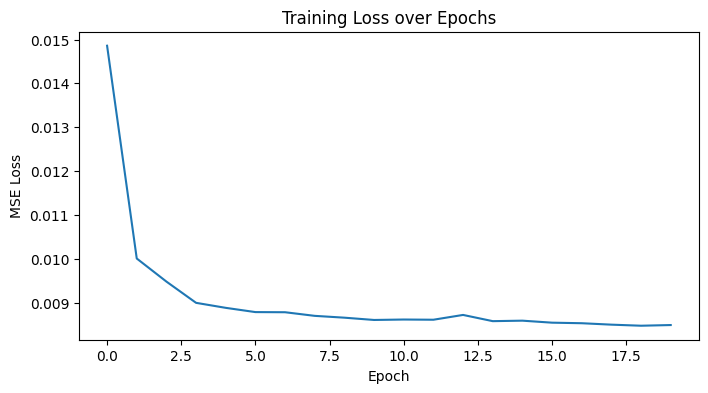

In [28]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [29]:
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        output = model(batch_x)
        predictions.extend(output.cpu().numpy())
        actuals.extend(batch_y.numpy())

predictions = np.array(predictions).reshape(-1, 1)
actuals = np.array(actuals).reshape(-1, 1)

# inverse transform back to real kW values
predictions_actual = scaler.inverse_transform(predictions)
actuals_actual = scaler.inverse_transform(actuals)

rmse = np.sqrt(np.mean((predictions_actual - actuals_actual) ** 2))
mae = np.mean(np.abs(predictions_actual - actuals_actual))

print(f"Test RMSE: {rmse:.4f} kW")
print(f"Test MAE: {mae:.4f} kW")

Test RMSE: 0.5027 kW
Test MAE: 0.3519 kW


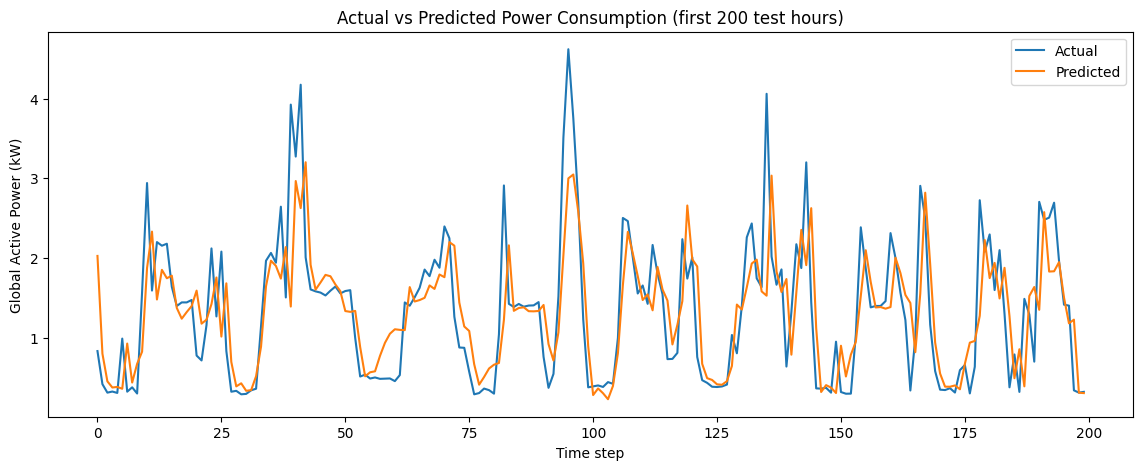

In [30]:
plt.figure(figsize=(14, 5))
plt.plot(actuals_actual[:200], label="Actual")
plt.plot(predictions_actual[:200], label="Predicted")
plt.title("Actual vs Predicted Power Consumption (first 200 test hours)")
plt.xlabel("Time step")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()

In [31]:
def predict_next_hour(model, last_24_hours, scaler, device):

    # last_24_hours: raw (unscaled) list/array of 24 readings
    scaled_input = scaler.transform(np.array(last_24_hours).reshape(-1, 1))

    input_tensor = torch.tensor(scaled_input, dtype=torch.float32).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    predicted_scaled = output.cpu().numpy().reshape(-1, 1)
    predicted_value = scaler.inverse_transform(predicted_scaled)

    return predicted_value[0][0]

last_window = hourly.values[-window_size:]
next_hour_pred = predict_next_hour(model, last_window, scaler, device)
print(f"Predicted next-hour Global Active Power: {next_hour_pred:.4f} kW")

Predicted next-hour Global Active Power: 0.9839 kW
